# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [17]:
!pip install numpy pandas

In [18]:
!python -m pip install numpy pandas

In [19]:
!pip install matplotlib

In [20]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

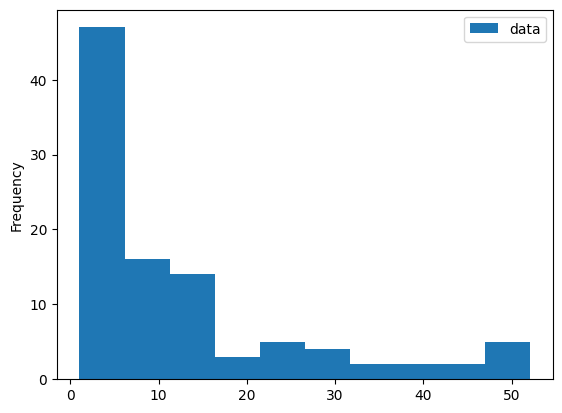

In [21]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

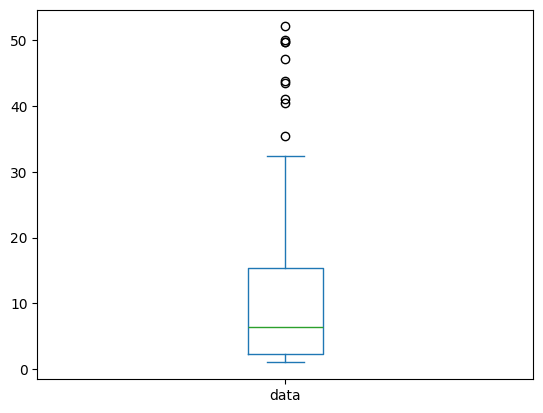

In [22]:
df.plot.box()

HISTOGRAM: The histogram does a great job of illustrating the full shape of the distribution, making it useful for identifying where drug prices cluster. In this case, prices cluster at the lower end and show a long right tail. This makes skewness, clustering, and potential peaks distinguishable. However, it is more difficult to extract exact summary statistics compared to a boxplot.

BOXPLOT: The boxplot’s strength lies in providing a clear summary of the median, quartiles, and outliers, which is helpful for demonstrating overall price trends and the extremity of higher-priced drugs. However, it does not display the detailed distribution shape, clustering patterns, or potential gaps in the data.

CONCLUSION: To properly inform the administrator about how much more expensive drugs tend to cost in the context of other prices, I would choose the boxplot because it clearly highlights the upper quartiles and outliers (the most expensive drugs). To improve the formatting, I would add a descriptive title and labeled axes, emphasize key reference points such as the median and 75th percentile, and refine the visualization settings to make extreme values easier to interpret.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [24]:
pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [kagglehub]10 [kagglesdk]
Note: you may need to restart the kernel to use updated packages.


In [25]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/Users/davidho/Downloads/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 66.0M/66.0M [00:59<00:00, 1.16MB/s]

Extracting files...


Path to dataset files: /Users/davidho/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [26]:
import os

file_path = os.path.join(path, "creditcard.csv")
fraud_df = pd.read_csv(file_path)

In [28]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [30]:
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [32]:
fraud_df["Class"].value_counts()
fraud_df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

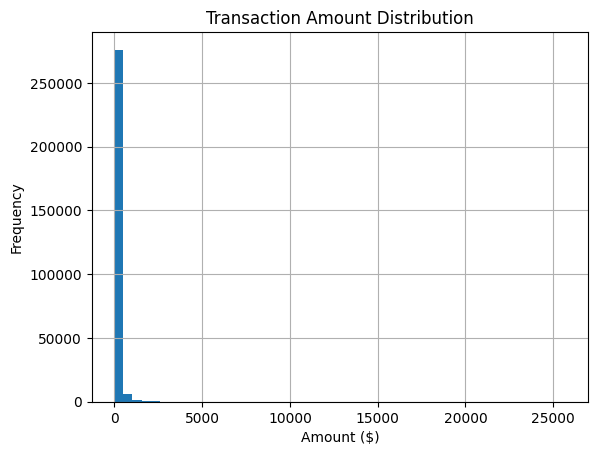

In [33]:
import matplotlib.pyplot as plt

fraud_df["Amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount ($)")
plt.ylabel("Frequency")
plt.show()

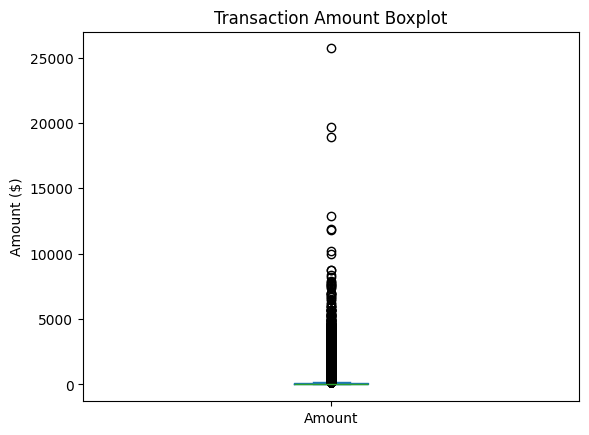

In [34]:
fraud_df["Amount"].plot.box()
plt.title("Transaction Amount Boxplot")
plt.ylabel("Amount ($)")
plt.show()

In [35]:
fraud_df["Amount"].mean()
fraud_df["Amount"].median()
fraud_df["Amount"].mode()

0    1.0
Name: Amount, dtype: float64

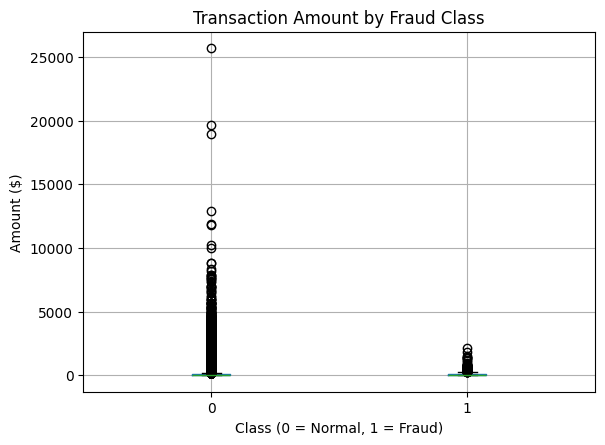

In [36]:
fraud_df.boxplot(column="Amount", by="Class")
plt.title("Transaction Amount by Fraud Class")
plt.suptitle("")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount ($)")
plt.show()

The transaction amount distribution is highly right-skewed, with most transactions occurring at low values and a small number of very large outliers. This is evident from both the histogram and boxplot, which show a heavy concentration near zero and a long right tail extending beyond $25,000. The median is much lower than the mean, confirming the presence of extreme values.

The dataset is highly imbalanced, with fraudulent transactions representing approximately 0.17% of all observations. This indicates that fraud detection models built on this data will need to account for class imbalance through techniques such as resampling or cost-sensitive learning.

When comparing transaction amounts by fraud class, non-fraudulent transactions tend to include more extreme high-value outliers, while fraudulent transactions are generally smaller in magnitude. Despite this imbalance, the dataset appears clean, complete, and suitable for analysis and modeling. However, special care will be required to ensure that rare fraud cases are properly represented in predictive models.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

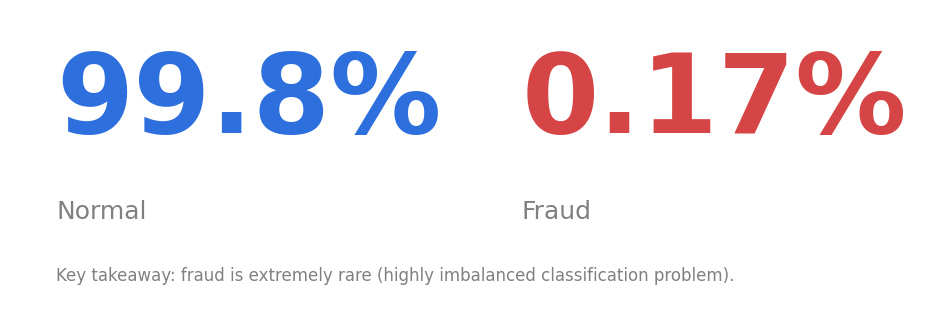

In [41]:
pct_fraud = (fraud_df["Class"].value_counts(normalize=True)[1] * 100)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

ax.text(0.05, 0.6, f"{pct_normal:.1f}%", fontsize=80, fontweight="bold", color="#2E6FDE")
ax.text(0.05, 0.32, "Normal", fontsize=18, color="gray")

ax.text(0.55, 0.6, f"{pct_fraud:.2f}%", fontsize=80, fontweight="bold", color="#D64545")
ax.text(0.55, 0.32, "Fraud", fontsize=18, color="gray")

ax.text(0.05, 0.12, "Key takeaway: fraud is extremely rare (highly imbalanced classification problem).",
        fontsize=12, color="gray")

plt.show()

I chose the simple text approach because the key insight of this dataset is a single, powerful statistic: fraud represents only 0.17% of transactions. Following Storytelling With Data principles, I removed all unnecessary visual elements and emphasized the number itself. This reduces cognitive load and immediately directs the audience to the core takeaway.

In [42]:
# Create amount bins
bins = [0, 10, 50, 100, 500, 1000, 5000, 30000]
labels = ["0-10", "10-50", "50-100", "100-500", "500-1k", "1k-5k", "5k+"]

fraud_df["Amount_bin"] = pd.cut(
    fraud_df["Amount"],
    bins=bins,
    labels=labels
)

In [43]:
# Create frequency table
heatmap_data = pd.crosstab(
    fraud_df["Amount_bin"],
    fraud_df["Class"]
)

# Rename columns
heatmap_data.columns = ["Normal", "Fraud"]

heatmap_data


,Normal,Fraud
Amount_bin,,
0–10,98217,222
10–50,90724,57
50–100,37198,56
100–500,47271,95
500–1k,6176,26
1k–5k,2876,9
5k+,55,0


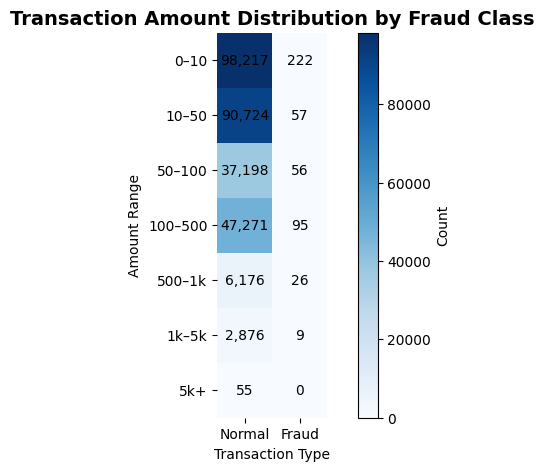

In [44]:
plt.figure(figsize=(8,5))

plt.imshow(heatmap_data, cmap="Blues")

# Titles and labels
plt.title("Transaction Amount Distribution by Fraud Class", fontsize=14, weight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Amount Range")

# Axis ticks
plt.xticks([0,1], ["Normal", "Fraud"])
plt.yticks(range(len(labels)), labels)

# Add numbers inside cells
for i in range(len(labels)):
    for j in range(2):
        plt.text(
            j, i,
            f"{heatmap_data.iloc[i, j]:,}",
            ha="center", va="center",
            color="black",
            fontsize=10
        )

# Remove clutter
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.colorbar(label="Count")

plt.show()

I included both a simple text visual and a heatmap to communicate different levels of insight. The simple text highlights the primary takeaway that fraud represents a very small proportion of transactions, allowing the audience to immediately grasp the key message. The heatmap provides supporting detail by showing how transaction amounts vary by fraud class. This combination balances clarity and depth while minimizing unnecessary visual complexity.